### Website Data analysis project

#### import libraries 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

#### Load Data set 

In [3]:
df = pd.read_csv("data-export (1).csv")

In [4]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [5]:
df.columns = df.iloc[0]
df = df.drop(index= 0).reset_index(drop= True)
df.columns = ["channel group", "Datehour", "Users","Sessions","Engaged sessions","Average engagement time per session","Engaged sessions per user","Events per session","Engagement rate","Event count"]
df.head(3)

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069


## Info of the data 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel group                        3182 non-null   object
 1   Datehour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


### check null values 

In [7]:
df.isnull().sum()

channel group                          0
Datehour                               0
Users                                  0
Sessions                               0
Engaged sessions                       0
Average engagement time per session    0
Engaged sessions per user              0
Events per session                     0
Engagement rate                        0
Event count                            0
dtype: int64

## Data cleaning and Validation 

### convert date hour column data type from object to  date time 

In [8]:
df["Datehour"] = pd.to_datetime(df["Datehour"],format="%Y%m%d%H", errors="coerce")

## convert rest of columnns from string to  numeric data type 

In [9]:
numeric_cols = df.columns.drop(["channel group","Datehour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric , errors = "coerce")
df.head()

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


### create new column of Hour

In [12]:
df["Hour"] = df["Datehour"].dt.hour

## Describe our data 

In [13]:
df.describe()

,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


## Data visulization 

### Sessions and users over Time 

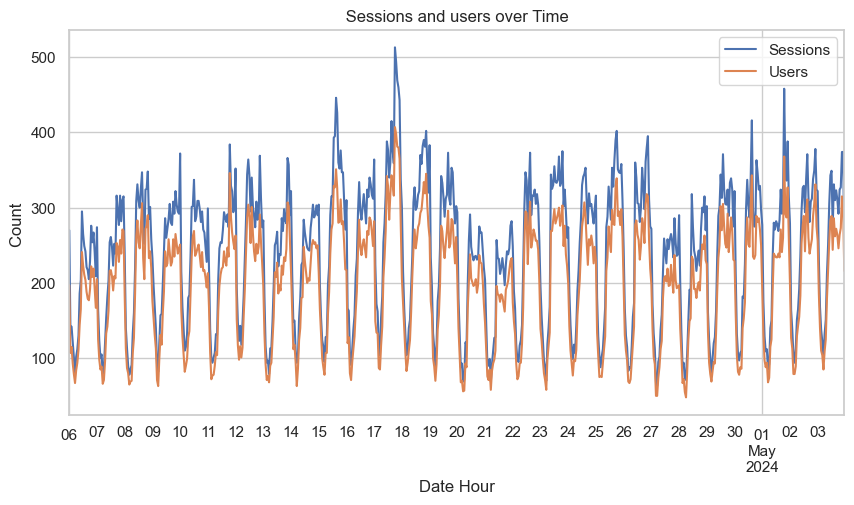

In [16]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
df.groupby("Datehour")[["Sessions","Users"]].sum().plot(ax=plt.gca())
plt.title(" Sessions and users over Time ")
plt.xlabel("Date Hour")
plt.ylabel("Count ")
plt.show()

### Total user by channel 

C:\Users\SC\AppData\Local\Temp\ipykernel_7504\2897195089.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df , x= "channel group", y= "Users" , estimator = np.sum , palette = "viridis")


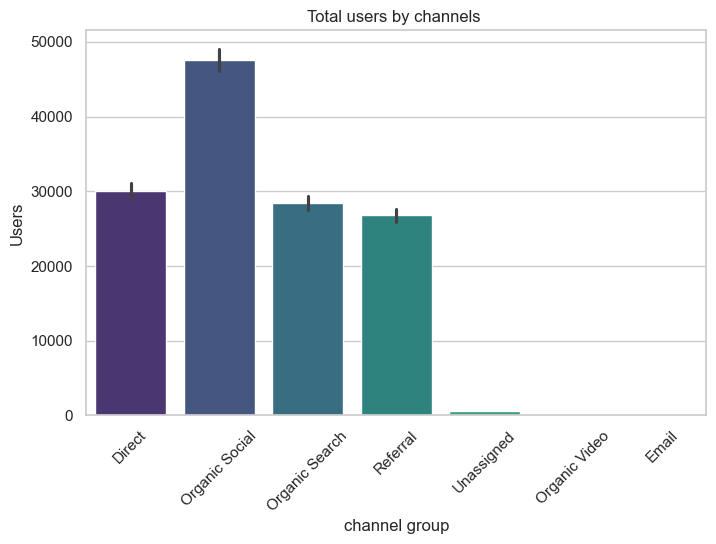

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df , x= "channel group", y= "Users" , estimator = np.sum , palette = "viridis")
plt.title("Total users by channels ")

plt.xticks(rotation = 45)
plt.show()

## Average Engagement Time By channel 

C:\Users\SC\AppData\Local\Temp\ipykernel_7504\1789767051.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df , x = "channel group", y = "Average engagement time per session" ,  estimator= np.mean, palette="magma")


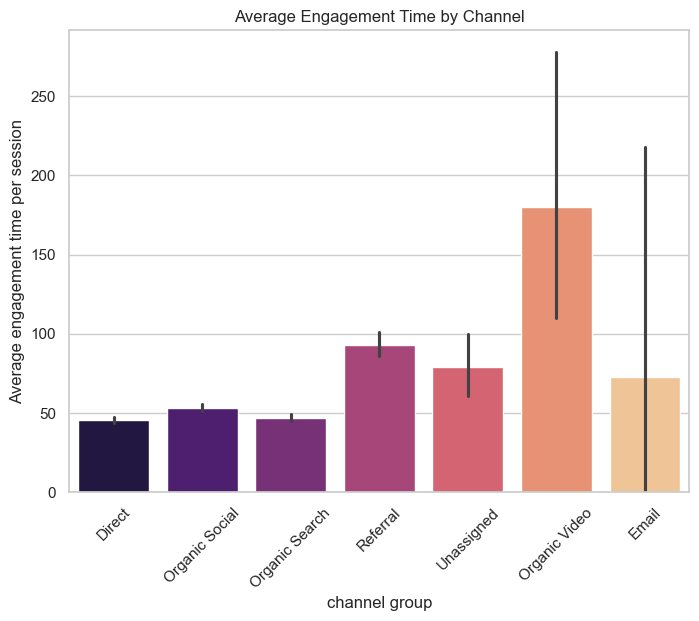

In [27]:
plt.figure(figsize=(8,6))
sns.barplot(data = df , x = "channel group", y = "Average engagement time per session" ,  estimator= np.mean, palette="magma")
plt.title("Average Engagement Time by Channel")
plt.xticks(rotation = 45)
plt.show()

## Engagement Rate  Distribution  by channels  

C:\Users\SC\AppData\Local\Temp\ipykernel_7504\1748337217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df , x= "channel group" , y = "Engagement rate" ,palette="coolwarm")


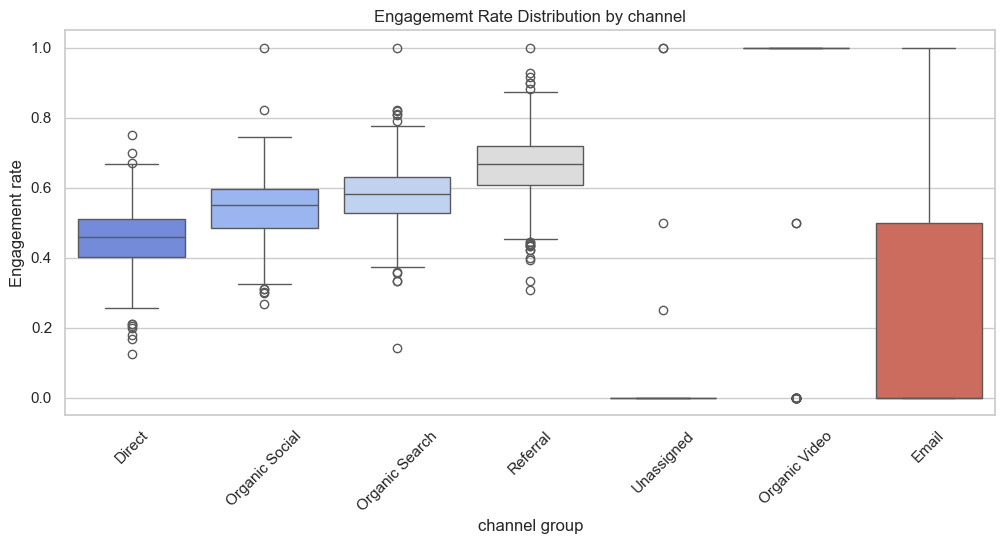

In [28]:
plt.figure(figsize=(12,5))
sns.boxplot(data= df , x= "channel group" , y = "Engagement rate" ,palette="coolwarm")
plt.title("Engagememt Rate Distribution by channel")
plt.xticks(rotation = 45)
plt.show()

### Engagement vs Non Engagement session

In [32]:
sessions_df = df.groupby("channel group")[["Sessions","Engaged sessions"]].sum().reset_index()
sessions_df["Non-Engag"] = sessions_df["Sessions"] - sessions_df["Engaged sessions"]
sessions_df_melted = sessions_df.melt(id_vars="channel group", value_vars=["Engaged sessions","Non-Engag"])

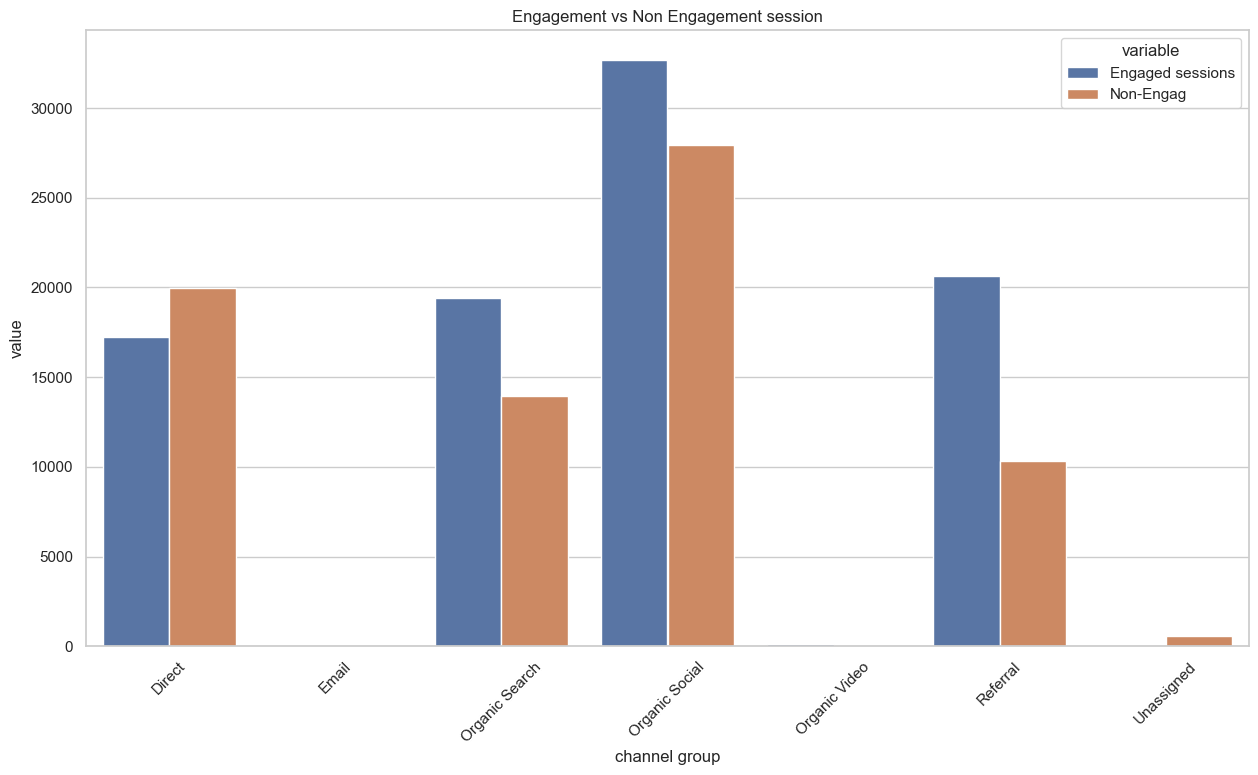

In [36]:
plt.figure(figsize=(15,8))
sns.barplot(data=sessions_df_melted , x="channel group",y= "value" ,hue="variable")
plt.title("Engagement vs Non Engagement session")
plt.xticks(rotation=45)
plt.show()

In [29]:
df.head()

,channel group,Datehour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
